<h1 style="font-size:2.8em; color:#1976d2; font-weight:bold">BÀI TOÁN PHÂN LOẠI CÁC LOẠI KHOÁNG THẠCH THÔNG QUA HÌNH ẢNH </h1>

# **📘 GIỚI THIỆU BÀI TOÁN**

***BÀI TẬP LỚN 3: HỌC MÁY VỚI DỮ LIỆU DẠNG ẢNH (IMAGE DATA)***

* **Giảng viên hướng dẫn**  
  * **Giảng viên: TS.Lê Thành Sách**

* **Nhóm MNTV:**
  * Tên: Huỳnh Đức Nhân - MSSV:2312420
  * Tên: Nguyễn Thiện Minh - MSSV: 2312097
  * Tên: Nguyễn Lưu Khánh Trình - MSSV: 2313638
  * Tên: Lê Công Vinh - MSSV: 2313912


* **Giới thiệu bài toán**
  * Xây dựng pipeline học máy truyền thống cho dữ liệu dạng ảnh, ở đây nhóm sử dụng bộ dữ liệu Mineral photos với khoảng 57 ngàn hình ảnh của các loại khoáng thạch như azurite, cerussite, copper,... với các định dạng khác nhau.

  * Mục tiêu của các mô hình là phân loại các loại khoáng thạch khác nhau dựa trên hình ảnh có sẵn trong tập dữ liệu.

  * Thông tin về bộ dữ liệu:
    * Tổng số mẫu: khoảng 57 ngàn file.
    * Format dữ liệu: Dữ liệu hình ảnh.
    * Định dạng: .png, .jpeg
    * Link dataset: [Kaggle - Minerals Identification Dataset](https://www.kaggle.com/datasets/floriangeillon/mineral-photos)


*  **Mục tiêu của bài toán**
    * Xây dựng pipeline học máy truyền thống hoàn chỉnh: Từ khâu tiền xử lý (tải dữ liệu, biến đổi ảnh (transforms), tăng cường dữ liệu (augmentation)) đến việc xây dựng, huấn luyện và đánh giá mô hình.

    * ***Phân tích chi tiết***: Đánh giá hiệu suất của mô hình thông qua các chỉ số đánh giá phân loại như **Accuracy (Độ chính xác)**, **Precision**, **Recall**, **F1-Score** và trực quan hóa kết quả bằng **Confusion Matrix (Ma trận nhầm lẫn)**.


* **Các mô hình sẽ được triển khai:**
    * SVM (Kernel RBF)
    * Logistic Regression
    * Random Forest
****

# **📌 Các thiết lập ban đầu**

## 📚 Giới thiệu các thư viện sử dụng

Trong quá trình xây dựng và huấn luyện mô hình **phân loại ảnh**, nhóm đã sử dụng nhiều thư viện Python phổ biến, hỗ trợ mạnh mẽ cho việc xử lý tệp tin, tiền xử lý dữ liệu hình ảnh, cũng như xây dựng các mô hình Deep Learning và Machine Learning.

## 1. Tiện ích cơ bản (Python & Hệ thống)
* `os`: Tương tác với hệ điều hành (đọc, ghi file, tạo thư mục).
* `zipfile`: Đọc và giải nén file ZIP.
* `random`: Tạo số ngẫu nhiên.
* `glob`: Tìm kiếm file theo mẫu (ví dụ: `*.jpg`).
* `shutil`: Tiện ích nâng cao về file (sao chép, di chuyển, xóa thư mục).
* `collections (defaultdict, Counter)`: Cung cấp các cấu trúc dữ liệu hữu ích (từ điển tự động gán giá trị mặc định, bộ đếm phần tử).
* `time`: Đo lường thời gian thực thi.
* `warnings`: Quản lý và ẩn các thông báo cảnh báo.

## 2. Xử lý dữ liệu & Trực quan hóa
* `numpy (np)`: Thư viện nền tảng cho tính toán số học, làm việc với mảng (matrix) hiệu suất cao.
* `pandas (pd)`: Đọc, ghi và xử lý dữ liệu dạng bảng (như CSV, Excel).
* `matplotlib.pyplot (plt)` & `matplotlib.image (mpimg)`: Thư viện chính để vẽ biểu đồ và hiển thị hình ảnh.
* `seaborn (sns)`: Thư viện xây dựng trên Matplotlib, giúp vẽ biểu đồ thống kê đẹp hơn.
* `PIL (Image)`: Thư viện mạnh mẽ để mở, xử lý và lưu nhiều định dạng hình ảnh.

## 3. Thư viện Học Sâu - PyTorch
* `torch`: Thư viện chính của PyTorch.
* `torch.nn (nn)` & `torch.nn.functional (F)`: Các khối xây dựng Mạng Nơ-ron (các lớp CNN, hàm kích hoạt, hàm mất mát).
* `torch.optim (optim)`: Chứa các thuật toán tối ưu hóa (ví dụ: Adam, SGD).
* `torch.utils.data (DataLoader, ...Sampler)`: Công cụ để tải và chia dữ liệu (tạo batch, xáo trộn dữ liệu).
* `torchvision`: Gói tiện ích của PyTorch dành riêng cho xử lý ảnh.
    * `torchvision.datasets (ImageFolder)`: Tải bộ dữ liệu ảnh có sẵn từ các thư mục.
    * `torchvision.transforms`: Các phép biến đổi và tăng cường hình ảnh (thay đổi kích thước, cắt, xoay).
    * `torchvision.models`: Chứa các kiến trúc mô hình nổi tiếng đã được huấn luyện trước (VGG16, ResNet, EfficientNet).

## 4. Thư viện Học Sâu - TensorFlow/Keras
*(Dùng cho phương pháp trích xuất đặc trưng hoặc so sánh)*
* `tensorflow (tf)`: Thư viện chính của TensorFlow.
* `tensorflow.keras.preprocessing.image (ImageDataGenerator)`: Tải và tăng cường dữ liệu ảnh cho Keras.
* `tensorflow.keras.applications (VGG16, ResNet50, ...)`: Các mô hình Keras đã được huấn luyện trước.
* `tensorflow.keras.models (Model)` & `layers (Input)`: Các khối xây dựng mô hình trong Keras.

## 5. Thư viện Học máy truyền thống - Scikit-learn
*(Dùng cho phương pháp trích xuất đặc trưng)*
* `sklearn.model_selection (train_test_split)`: Chia dữ liệu thành tập huấn luyện và tập kiểm tra.
* `sklearn.linear_model (LogisticRegression)`: Mô hình Hồi quy Logistic.
* `sklearn.svm (SVC)`: Mô hình Support Vector Machine (SVM) để phân loại.
* `sklearn.ensemble (RandomForestClassifier)`: Mô hình Rừng ngẫu nhiên (Random Forest).
* `sklearn.metrics (accuracy_score, ...)`: Các hàm để đo lường độ chính xác và đánh giá mô hình.



**Cấu hình bổ sung:** Nhóm định nghĩa hằng số `IMG_SIZE = (224, 224)` để đảm bảo tất cả hình ảnh đầu vào đều được điều chỉnh về kích thước chuẩn, phù hợp với yêu cầu của các mô hình CNN pre-trained.

In [ ]:
import os
import zipfile
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import h5py
from PIL import Image
from glob import glob
from collections import defaultdict
import warnings
import shutil
from collections import Counter
import time
import torch.optim as optim
from torch.utils.data import SubsetRandomSampler
from torch.utils.data import DataLoader, SubsetRandomSampler
from torch.utils.data import DataLoader, SubsetRandomSampler, WeightedRandomSampler
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

import torchvision.models as models
from torchvision.models import EfficientNet_B0_Weights

from torchvision.datasets import ImageFolder
from torchvision import datasets, transforms
import torch
import torch.nn as nn
import torch.nn.functional as F

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from tqdm import tqdm

IMG_SIZE = (224, 224)

# **📥 Tải và kiểm tra dữ liệu**

## *Tải dữ liệu*

Đầu tiên, nhóm tiến hành tải bộ dữ liệu ảnh Minerals Identification Dataset từ **Kaggle** thông qua thư viện `kagglehub` bằng cách sử dụng `kagglehub.dataset_download(...)` để tải bộ dữ liệu từ Kaggle.

Bộ dữ liệu được tổ chức theo cấu trúc thư mục. Trong đó, **mỗi thư mục con đại diện cho một lớp (class)**, tức là một loại khoáng sản cụ thể, chứa tất cả các hình ảnh thuộc về lớp đó



In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("floriangeillon/mineral-photos")

print("Path to dataset files:", path)

100%|██████████| 14.8G/14.8G [02:41<00:00, 98.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/floriangeillon/mineral-photos/versions/6


Tuy nhiên do số lượng sample quá lớn trong tập dữ liệu nên trong bài tập lớn này. Chúng tôi quyết định sẽ chỉ thực hiện việc phân biệt khoáng thạch trên 7 lọai khác nhau bao gồm:
* Azurite  
* Cerussite  
* Copper  
* Gypsum  
* Hematite  
* Malachite  
* Wulfenite

In [ ]:
# 1. Tạo một thư mục mới để chứa dữ liệu của bạn
!mkdir -p /kaggle/working/my_data
print("Đang copy azurite...")
!cp -r /root/.cache/kagglehub/datasets/floriangeillon/mineral-photos/versions/6/data/data/azurite /kaggle/working/my_data/
print("Đang copy cerussite...")
!cp -r /root/.cache/kagglehub/datasets/floriangeillon/mineral-photos/versions/6//data/data/cerussite /kaggle/working/my_data/
print("Đang copy copper...")
!cp -r /root/.cache/kagglehub/datasets/floriangeillon/mineral-photos/versions/6//data/data/copper /kaggle/working/my_data/
print("Đang copy gypsum...")
!cp -r /root/.cache/kagglehub/datasets/floriangeillon/mineral-photos/versions/6//data/data/gypsum /kaggle/working/my_data/
print("Đang copy hematite...")
!cp -r /root/.cache/kagglehub/datasets/floriangeillon/mineral-photos/versions/6//data/data/hematite /kaggle/working/my_data/
print("Đang copy malachite...")
!cp -r /root/.cache/kagglehub/datasets/floriangeillon/mineral-photos/versions/6//data/data/malachite /kaggle/working/my_data/
print("Đang copy wulfenite...")
!cp -r /root/.cache/kagglehub/datasets/floriangeillon/mineral-photos/versions/6//data/data/wulfenite  /kaggle/working/my_data/
!ls /kaggle/working/my_data

Đang copy azurite...
Đang copy cerussite...
Đang copy copper...
Đang copy gypsum...
Đang copy hematite...
Đang copy malachite...
Đang copy wulfenite...
azurite  cerussite  copper  gypsum  hematite  malachite  wulfenite



Hiển thị các ảnh mẫu:


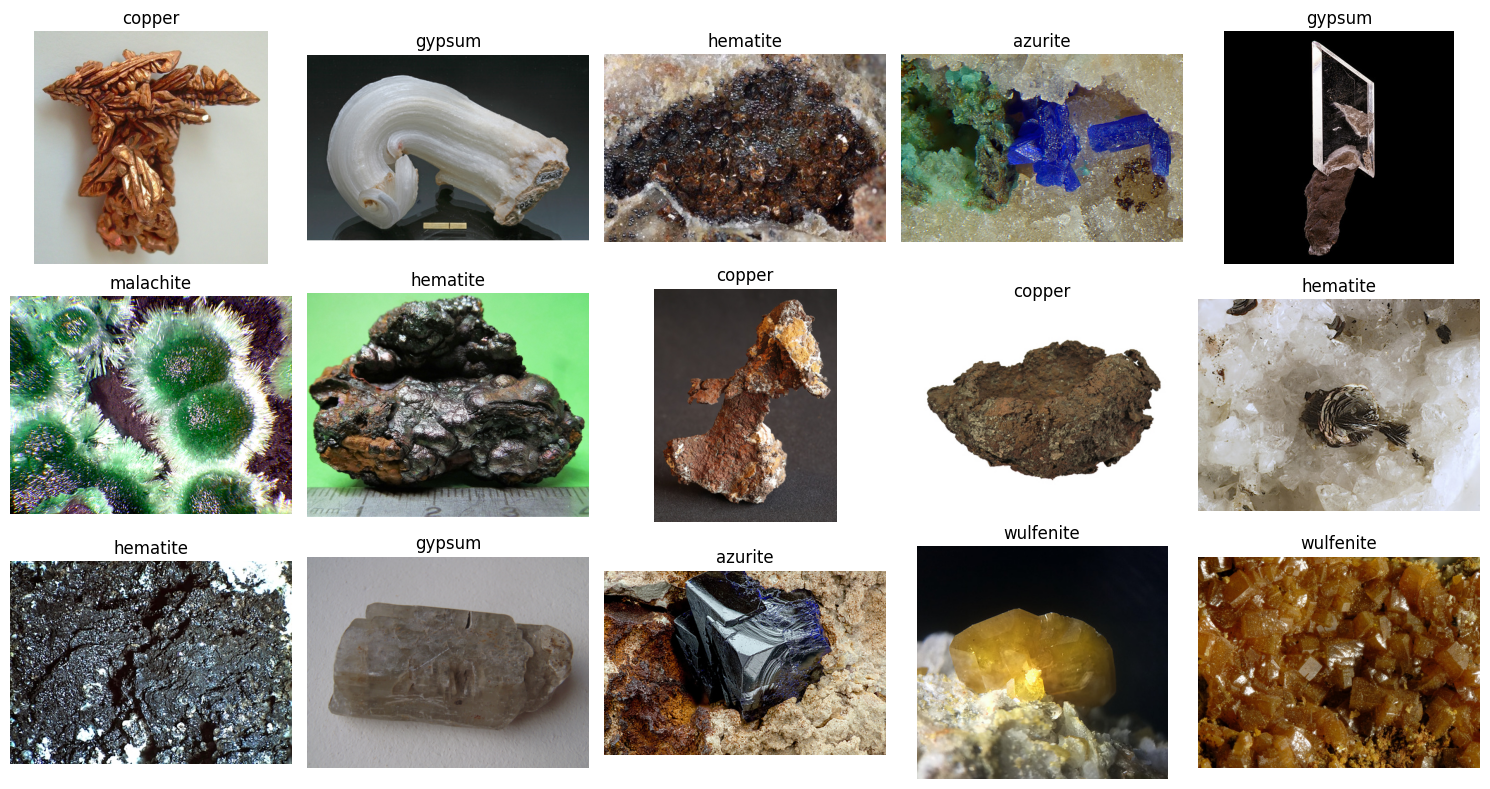

In [ ]:
path = "/kaggle/working/my_data"
data_dir = os.path.join(path)
class_names = os.listdir(data_dir)

# Hàm để hiển thị ảnh mẫu
def show_sample_images(directory, class_names, num_rows=3, num_cols=5):
    plt.figure(figsize=(15, 8))
    for i in range(num_rows * num_cols):
        # Random 1 lớp
        random_class = random.choice(class_names)
        class_path = os.path.join(directory, random_class)

        # Random 1 ảnh trong lớp đó
        try:
            random_image = random.choice(os.listdir(class_path))
            image_path = os.path.join(class_path, random_image)

            # Hiển thị ảnh
            img = mpimg.imread(image_path)
            plt.subplot(num_rows, num_cols, i + 1)
            plt.imshow(img)
            plt.title(random_class)
            plt.axis('off')
        except (IOError, IndexError):
            # Bỏ qua nếu thư mục rỗng hoặc file ảnh bị lỗi
            pass
    plt.tight_layout()
    plt.show()

print("\nHiển thị các ảnh mẫu:")
show_sample_images(data_dir, class_names)

# **📊 EDA - Khám phá dữ liệu**

## 🔍 Phân tích Tổng quan Bộ Dữ liệu Khoáng sản

Trong lớp được chọn ra trong bộ dữ liệu **Mineral photos** có phân bố số lượng mẫu như bảng dưới đây:

| Lớp | Số lượng Mẫu |
| :--- | ---: |
| **Malachite** | 1607 |
| **Wulfenite** | 1521 |
| **Copper** | 1429 |
| **Cerussite** | 1367 |
| **Gypsum** | 1351 |
| **Hematite** | 1284 |
| **Azurite** | 1250 |

**Nhận xét:**  
Có sự chênh lệch giữa lớp có nhiều mẫu nhất (**Malachite**, 1607 mẫu) và lớp ít nhất (**Azurite**, 1250 mẫu).  
Tuy mức độ chênh lệch không quá lớn, nhưng vẫn cần xem xét **kỹ thuật cân bằng dữ liệu** (như oversampling, augmentation hoặc weighted loss) khi huấn luyện mô hình.



Thống kê số lượng ảnh mỗi lớp:
       Class  Count
1  malachite   1607
3  wulfenite   1521
2     copper   1429
5  cerussite   1367
0     gypsum   1351
4   hematite   1284
6    azurite   1250


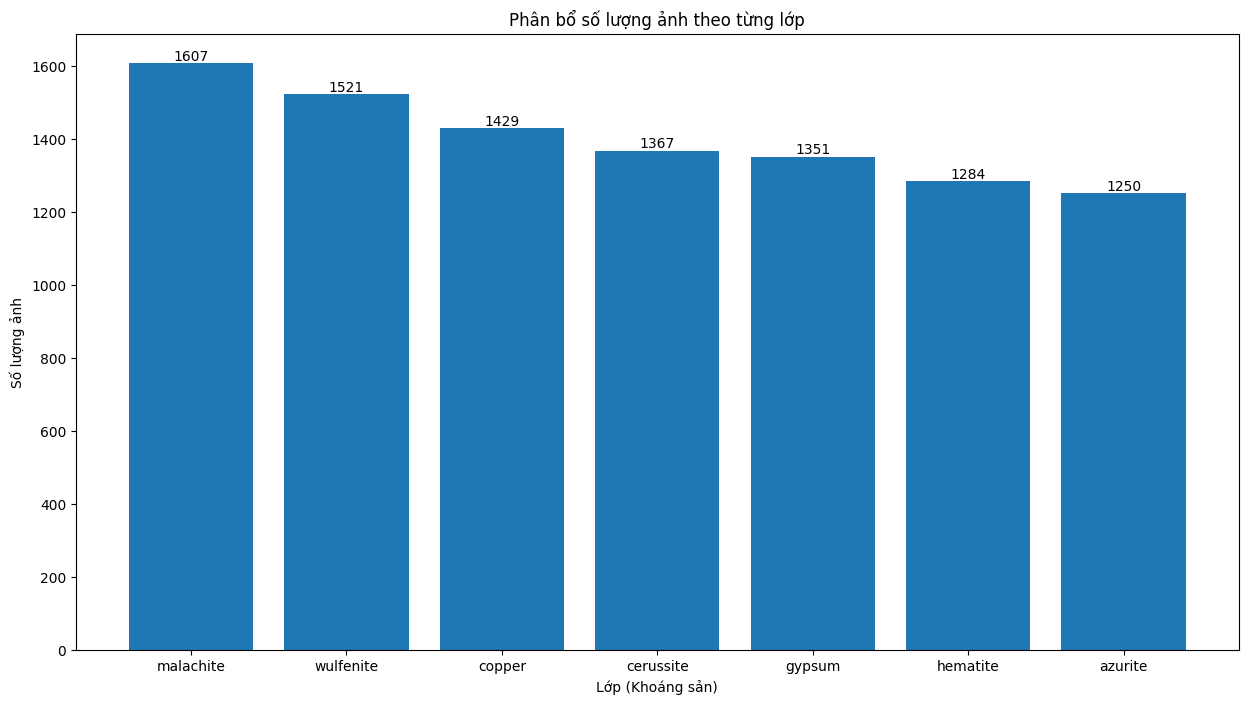

In [ ]:
# Đếm số lượng ảnh trong mỗi lớp
image_count_per_class = []
for class_name in class_names:
    class_path = os.path.join(data_dir, class_name)
    # Kiểm tra xem có phải là thư mục không
    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        image_count_per_class.append({'Class': class_name, 'Count': count})

df_class_counts = pd.DataFrame(image_count_per_class)
df_class_counts = df_class_counts.sort_values('Count', ascending=False)

print("\nThống kê số lượng ảnh mỗi lớp:")
print(df_class_counts.head(10))


# Vẽ biểu đồ
plt.figure(figsize=(15, 8))
bars = plt.bar(df_class_counts['Class'], df_class_counts['Count'])
plt.title('Phân bổ số lượng ảnh theo từng lớp')
plt.xlabel('Lớp (Khoáng sản)')
plt.ylabel('Số lượng ảnh')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval,
             int(yval),
             ha='center',
             va='bottom')

plt.show()


## 🔍 Phân tích về dịnh dạng các hình ảnh
Kết quả thống kê cho thấy toàn bộ hình ảnh đều là các định dạng ảnh hợp lệ (.jpg, .png, .jpeg), điều này rất tốt cho việc huấn luyện. Với số lượng ảnh có định dạng jneg có số lượng áp đảo với hơn 9700 ảnh thuộc định dạng này trong khi với png con số chỉ là 25


Thống kê số lượng tệp theo định dạng:
Định dạng  Số lượng
     jpeg      9784
      png        25
----------------------------------------


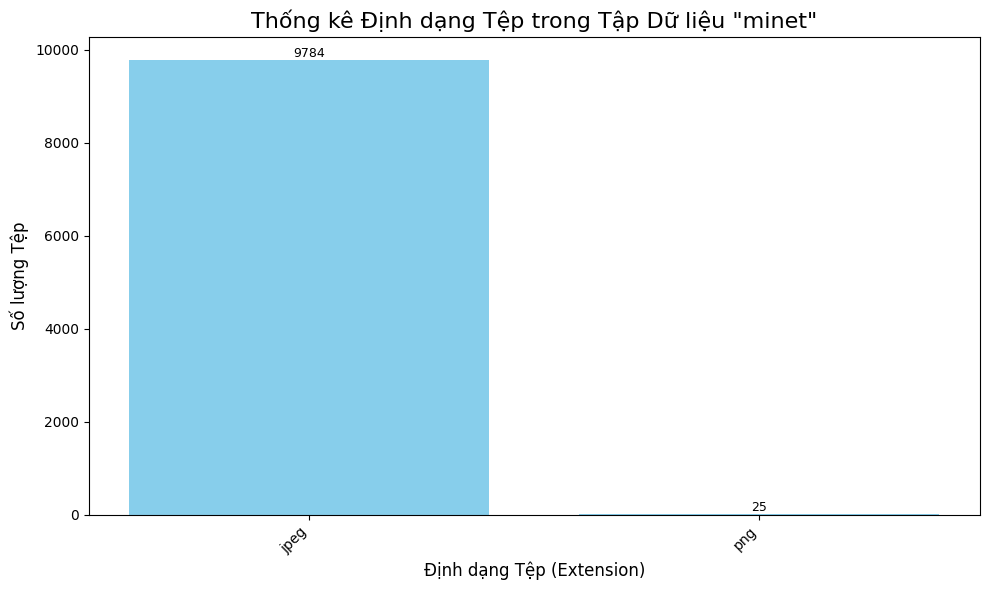

In [ ]:
extension_counts = defaultdict(int)
for root, dirs, files in os.walk(data_dir):
    for file in files:
        # Tách lấy phần mở rộng (đuôi) tệp
        _, ext = os.path.splitext(file)

        # Chuẩn hóa:
        ext = ext.lower().lstrip('.')

        if not ext:
            ext = 'Không có đuôi'

        extension_counts[ext] += 1

# 3. Chuyển sang DataFrame để dễ dàng sắp xếp và vẽ biểu đồ
df_counts = pd.DataFrame(list(extension_counts.items()), columns=['Định dạng', 'Số lượng'])

print("Thống kê số lượng tệp theo định dạng:")
print(df_counts.to_string(index=False))
print("-" * 40)

# 4. Vẽ biểu đồ
plt.figure(figsize=(10, 6))

bars = plt.bar(df_counts['Định dạng'], df_counts['Số lượng'], color='skyblue')

plt.title('Thống kê Định dạng Tệp trong Tập Dữ liệu "minet"', fontsize=16)
plt.xlabel('Định dạng Tệp (Extension)', fontsize=12)
plt.ylabel('Số lượng Tệp', fontsize=12)


plt.xticks(rotation=45, ha='right')


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 🔍 Nhận xét chung về các ảnh trong tập dữ liệu

* Tập dữ liệu này không tồn tại các file không thuộc định dạng ảnh và không tồn tại luôn file hỏng

* Hiện tại, xét về kênh màu, đa số là RGB hơn 9700 ảnh và số ít là các kênh màu RGBA, L và CMYK. Tuy có số lượng ít những để đảm bảo giữ được tối đa số lượng mẫu thì vẫn nên cân nhắc đến việc chuyển đổi các kênh màu đó thanh RGB.

* Về kích thước ảnh, thống kê cho thấy sự không đồng nhất, với nhiều kích cỡ và tỷ lệ khung hình khác nhau. Với sự đa dạng về kích thước đó, để đảm bảo mô hình đạt được kết quả tốt nhất, từ đó phải chuẩn hóa kích thước đầu vào.

Tổng cộng: 0 file bị bỏ qua (không phải .png, .jpg, .jpeg).
Tổng cộng: 0 file ảnh (có đuôi hợp lệ) bị hỏng.
Không tìm thấy file ảnh hỏng nào (.png, .jpg, .jpeg).

PHÂN TÍCH KÊNH MÀU (Color Modes)
RGB     9783
RGBA      19
L          4
CMYK       3
Name: count, dtype: int64


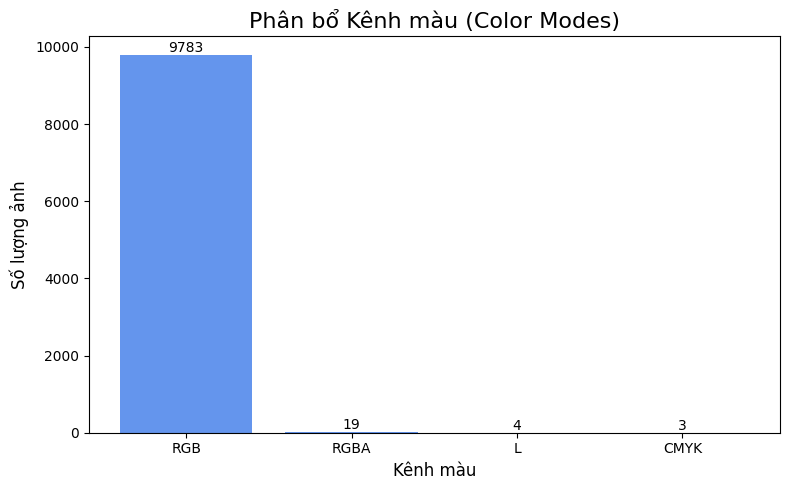


PHÂN TÍCH KÍCH THƯỚC ẢNH
Top 10 kích thước ảnh phổ biến nhất:
(400, 300)      1012
(400, 266)       608
(400, 267)       577
(400, 400)       374
(1280, 960)      280
(400, 265)       160
(400, 533)       102
(1600, 1200)      87
(400, 270)        84
(400, 268)        57
Name: count, dtype: int64


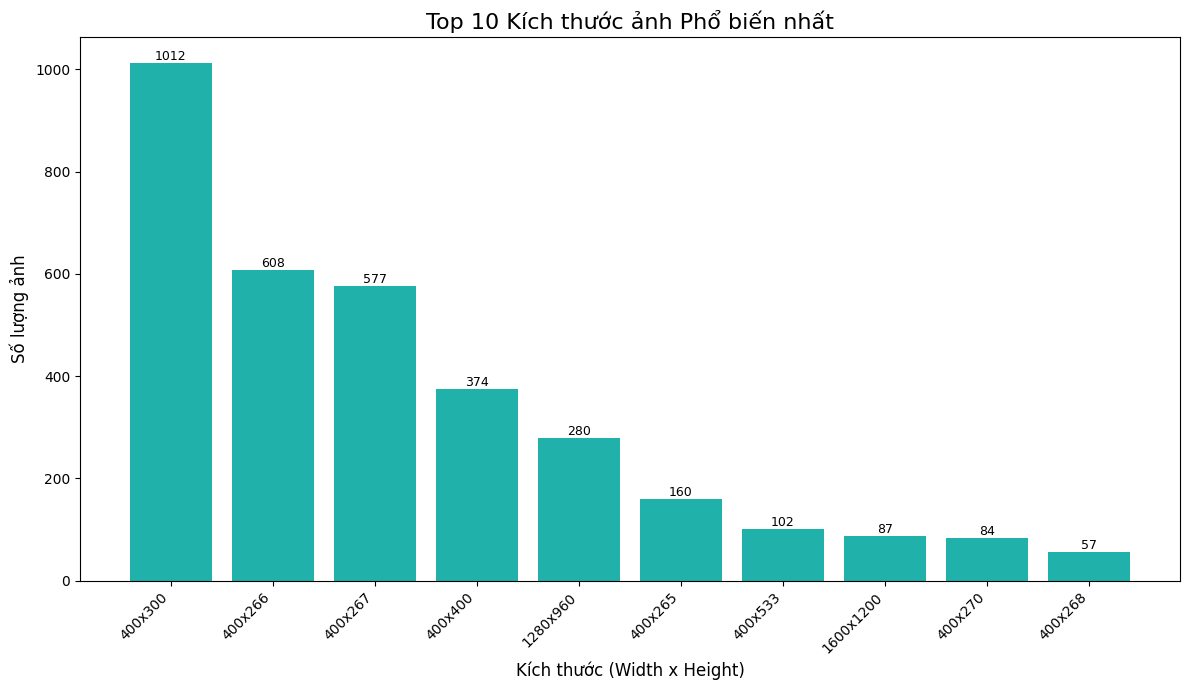

In [ ]:
# --- Bắt đầu EDA (Kích thước & Kênh màu) ---

all_sizes = []
all_modes = []
corrupted_files = []
skipped_files = []

VALID_IMAGE_EXTENSIONS = {'.png', '.jpg', '.jpeg'}

# Quét qua tất cả các file
for cls in class_names:
    class_path = os.path.join(data_dir, cls)
    if not os.path.isdir(class_path):
        continue

    for img_file in os.listdir(class_path):
        img_path = os.path.join(class_path, img_file)

        _, file_extension = os.path.splitext(img_file)
        file_extension = file_extension.lower()

        if file_extension in VALID_IMAGE_EXTENSIONS:
            try:
                with Image.open(img_path) as img:
                    all_sizes.append(img.size)
                    all_modes.append(img.mode)
            except Exception as e:
                corrupted_files.append(img_path)
        else:
            skipped_files.append(img_path)


print(f"Tổng cộng: {len(skipped_files)} file bị bỏ qua (không phải .png, .jpg, .jpeg).")
print(f"Tổng cộng: {len(corrupted_files)} file ảnh (có đuôi hợp lệ) bị hỏng.")

# Phần in ra file hỏng và file bỏ qua
if len(skipped_files) > 0:
    print("\n" + "="*30)
    print("DANH SÁCH CÁC FILE BỊ BỎ QUA (đuôi tệp không hợp lệ):")
    print("="*30)
    for f_path in skipped_files[:10]:
        print(f_path)
    if len(skipped_files) > 10:
        print(f"(và {len(skipped_files) - 10} file khác...)")
    print("\nLý do: Các file này không có đuôi .png, .jpg, hoặc .jpeg.")

if len(corrupted_files) > 0:
    print("\n" + "="*30)
    print("DANH SÁCH CÁC FILE ẢNH BỊ HỎNG (Corrupted):")
    print("="*30)
    for f_path in corrupted_files:
        print(f_path)
    print("\nLý do: Các file này CÓ đuôi ảnh hợp lệ nhưng nội dung file bị lỗi.")
else:
    print("Không tìm thấy file ảnh hỏng nào (.png, .jpg, .jpeg).")

# --- 1. Phân tích Kênh màu (Số kênh) ---
print("\n" + "="*30)
print("PHÂN TÍCH KÊNH MÀU (Color Modes)")
print("="*30)
if len(all_modes) > 0:
    mode_counts = pd.Series(all_modes).value_counts()
    print(mode_counts)
else:
    print("Không tìm thấy ảnh hợp lệ để phân tích.")

    # --- 1. Vẽ biểu đồ cho KÊNH MÀU ---
if len(all_modes) > 0:
    plt.figure(figsize=(8, 5))

    bars = plt.bar(mode_counts.index, mode_counts.values, color='cornflowerblue')

    plt.title('Phân bổ Kênh màu (Color Modes)', fontsize=16)
    plt.xlabel('Kênh màu', fontsize=12)
    plt.ylabel('Số lượng ảnh', fontsize=12)

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval),
                 ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

# --- 2. Phân tích Kích thước ảnh ---
print("\n" + "="*30)
print("PHÂN TÍCH KÍCH THƯỚC ẢNH")
print("="*30)
if len(all_sizes) > 0:
    size_counts = pd.Series(all_sizes).value_counts()
    print("Top 10 kích thước ảnh phổ biến nhất:")
    print(size_counts.head(10))
else:
    print("Không tìm thấy ảnh hợp lệ để phân tích.")

# --- 2. Vẽ biểu đồ cho KÍCH THƯỚC ẢNH (Top 10) ---
if len(all_sizes) > 0:
    top_10_sizes = size_counts.head(10)

    labels = [f"{w}x{h}" for w, h in top_10_sizes.index]
    values = top_10_sizes.values

    plt.figure(figsize=(12, 7))
    bars = plt.bar(labels, values, color='lightseagreen')

    plt.title('Top 10 Kích thước ảnh Phổ biến nhất', fontsize=16)
    plt.xlabel('Kích thước (Width x Height)', fontsize=12)
    plt.ylabel('Số lượng ảnh', fontsize=12)

    plt.xticks(rotation=45, ha='right')

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval),
                 ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

## 📝 Xử lý các file không cần thiết, kênh màu và kích thước ảnh

In [ ]:
# Tắt các cảnh báo từ PIL
Image.MAX_IMAGE_PIXELS = None
warnings.simplefilter('ignore', Image.DecompressionBombWarning)

print(f"--- BẮT ĐẦU QUÁ TRÌNH LÀM SẠCH VÀ CHUẨN HÓA ---")
print(f"Thư mục mục tiêu: {data_dir}\n")

VALID_IMAGE_EXTENSIONS = {'.png', '.jpg', '.jpeg'}

# Biến đếm thống kê
deleted_count = 0
converted_count = 0
already_ok_count = 0
error_count = 0
deleted_dir_count = 0

for item_name in class_names:
    item_path = os.path.join(data_dir, item_name)

    # ---nKIỂM TRA CẤP 1: Xóa .ipynb_checkpoints trong data_dir ---
    if item_name == '.ipynb_checkpoints' and os.path.isdir(item_path):
        try:
            shutil.rmtree(item_path)
            print(f"  [Đã xóa] Thư mục checkpoint: {item_path}")
            deleted_dir_count += 1
        except Exception as e:
            print(f"  [Lỗi xóa] Không thể xóa {item_path}: {e}")
            error_count += 1
        continue


    # Nếu không phải thư mục (ví dụ: file rác ở thư mục gốc), bỏ qua
    if not os.path.isdir(item_path):
        continue

    print(f"--- Đang xử lý lớp: {item_name} ---")

    # Duyệt qua từng file trong thư mục lớp
    for img_file in os.listdir(item_path):
        img_path = os.path.join(item_path, img_file)

        # --- KIỂM TRA CẤP 2: Xóa .ipynb_checkpoints trong thư mục lớp ---
        if img_file == '.ipynb_checkpoints' and os.path.isdir(img_path):
            try:
                shutil.rmtree(img_path)
                print(f"  [Đã xóa] Thư mục checkpoint: {img_path}")
                deleted_dir_count += 1
            except Exception as e:
                print(f"  [Lỗi xóa] Không thể xóa {img_path}: {e}")
                error_count += 1
            continue


        # Bỏ qua nếu là thư mục con (không phải .ipynb_checkpoints)
        if os.path.isdir(img_path):
            continue

        # --- 1. Lược bỏ các file bị bỏ qua ---
        _, file_extension = os.path.splitext(img_file)
        file_extension = file_extension.lower()

        if file_extension not in VALID_IMAGE_EXTENSIONS:
            try:
                os.remove(img_path)
                print(f"  [Đã xóa] File không hợp lệ: {img_file}")
                deleted_count += 1
            except Exception as e:
                print(f"  [Lỗi xóa] Không thể xóa {img_file}: {e}")
                error_count += 1
            continue

        # --- 2. Xử lý các file có đuôi hợp lệ  ---
        try:
            with Image.open(img_path) as img:

                # --- 3. Thiết lập lại kênh màu là RGB ---
                if img.mode != 'RGB':
                    rgb_img = img.convert('RGB')
                    rgb_img.save(img_path)
                    print(f"  [Đã chuyển đổi] File: {img_file} (từ {img.mode} -> RGB)")
                    converted_count += 1
                else:
                    already_ok_count += 1

        except Exception as e:
            # Xử lý File bị hỏng
            print(f"  [Lỗi - Đã xóa] File ảnh hỏng: {img_file} - Lỗi: {e}")
            try:
                os.remove(img_path)
                deleted_count += 1
            except Exception as e_del:
                print(f"  [Lỗi xóa] Không thể xóa file hỏng {img_file}: {e_del}")
                error_count += 1

print("\n" + "="*50)
print("--- QUÁ TRÌNH HOÀN TẤT ---")
print(f"Đã xóa (thư mục .ipynb_checkpoints): {deleted_dir_count} thư mục")
print(f"Đã xóa (file không hợp lệ/hỏng):   {deleted_count} file")
print(f"Đã chuyển đổi sang RGB:           {converted_count} file")
print(f"Đã chuẩn (RGB/không hỏng):         {already_ok_count} file")
print(f"Bị lỗi (không thể xử lý/xóa):    {error_count} file")
print("="*50)
print("Bộ dữ liệu của bạn hiện đã được làm sạch và chuẩn hóa về kênh màu RGB.")

--- BẮT ĐẦU QUÁ TRÌNH LÀM SẠCH VÀ CHUẨN HÓA ---
Thư mục mục tiêu: /kaggle/working/my_data

--- Đang xử lý lớp: gypsum ---
  [Đã chuyển đổi] File: image_0063436.jpeg (từ CMYK -> RGB)
  [Đã chuyển đổi] File: image_0077366.png (từ RGBA -> RGB)
  [Đã chuyển đổi] File: image_0067050.png (từ RGBA -> RGB)
  [Đã chuyển đổi] File: image_0077367.png (từ RGBA -> RGB)
--- Đang xử lý lớp: malachite ---
  [Đã chuyển đổi] File: image_0067865.png (từ RGBA -> RGB)
  [Đã chuyển đổi] File: image_0062620.jpeg (từ L -> RGB)
  [Đã chuyển đổi] File: image_0045263.png (từ RGBA -> RGB)
--- Đang xử lý lớp: copper ---
  [Đã chuyển đổi] File: image_0076297.png (từ RGBA -> RGB)
  [Đã chuyển đổi] File: image_0076295.png (từ RGBA -> RGB)
  [Đã chuyển đổi] File: image_0068171.png (từ RGBA -> RGB)
  [Đã chuyển đổi] File: image_0062248.png (từ RGBA -> RGB)
--- Đang xử lý lớp: wulfenite ---
  [Đã chuyển đổi] File: image_0065010.png (từ RGBA -> RGB)
  [Đã chuyển đổi] File: image_0079450.png (từ RGBA -> RGB)
  [Đã chuyển 

# Trích xuất Đặc trưng (Feature Extraction) với EfficientNet-B0

Mục tiêu của đoạn code này là **trích xuất các vector đặc trưng** từ một bộ dữ liệu hình ảnh. Thay vì huấn luyện một mô hình từ đầu, chúng ta sử dụng một mô hình **EfficientNet-B0** đã được huấn luyện trước (pretrained) trên ImageNet.

Đây là tóm tắt các bước chính:

1.  **Thiết lập:** Xác định thiết bị (GPU/CPU), thư mục dữ liệu và kích thước batch.
2.  **Xử lý Dữ liệu "An toàn" (Safe Loading):**
    * Code này sử dụng một lớp `SafeImageFolder` và hàm `safe_collate` tùy chỉnh.
    * **Lợi ích:** Điều này cho phép quá trình tải dữ liệu **bỏ qua bất kỳ tệp ảnh nào bị hỏng** hoặc không thể đọc được, thay vì làm sập toàn bộ chương trình.
3.  **Tải Mô hình:** Tải mô hình `efficientnet_b0` với các trọng số (weights) được huấn luyện trước.
4.  **Sửa đổi Mô hình:**
    * Đây là bước then chốt. Lớp `classifier` (lớp phân loại tuyến tính cuối cùng) của mô hình được **thay thế bằng `nn.Identity()`**.
    * Kết quả là, khi một hình ảnh đi qua mô hình, đầu ra không phải là dự đoán (ví dụ: "chó" hay "mèo"), mà là **vector đặc trưng 1280 chiều** mà mô hình đã học được ngay trước lớp phân loại đó.
5.  **Vòng lặp Trích xuất:**
    * Chạy toàn bộ bộ dữ liệu qua mô hình đã sửa đổi (ở chế độ `eval()` và `torch.no_grad()` để tiết kiệm bộ nhớ và tăng tốc).
    * Thu thập tất cả các vector đặc trưng và nhãn (labels) tương ứng.
6.  **Lưu trữ Kết quả:**
    * Nối (concatenate) tất cả các đặc trưng và nhãn từ các batch thành hai mảng NumPy lớn.
    * Lưu cả hai mảng này vào một tệp HDF5 (`extracted_data.h5`). Tệp này có thể được sử dụng sau này để huấn luyện các mô hình học máy khác (như SVM, XGBoost) hoặc cho các tác vụ phân cụm.

In [ ]:
data_dir = "/kaggle/working/my_data"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128

print(f"Sử dụng thiết bị: {device}")
print(f"Thư mục dữ liệu: {data_dir}")

# --- Transform ---
extraction_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- Code Tải Dữ liệu An toàn  ---
IMG_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.ppm', '.bmp', '.pgm', '.tif', '.tiff', '.webp')

def is_valid_image(path):
    return path.lower().endswith(IMG_EXTENSIONS)

class SafeImageFolder(Dataset):
    def __init__(self, root, transform=None):
        self.dataset = ImageFolder(root, transform=transform, is_valid_file=is_valid_image)
        self.classes = self.dataset.classes
        self.class_to_idx = self.dataset.class_to_idx
        self.samples = self.dataset.samples
        self.targets = self.dataset.targets

    def __getitem__(self, index):
        try:
            return self.dataset[index]
        except Exception as e:
            # Bỏ qua file hỏng và trả về None
            return None

    def __len__(self):
        return len(self.dataset)

def safe_collate(batch):
    batch = [item for item in batch if item is not None]
    if not batch:
        return torch.empty(0), torch.empty(0)
    return torch.utils.data.dataloader.default_collate(batch)

# --- Tạo Dataset và DataLoader ---
print("Đang tải dữ liệu (chế độ an toàn)...")
full_dataset = SafeImageFolder(data_dir, transform=extraction_transform)

full_loader = DataLoader(full_dataset,
                         batch_size=batch_size,
                         shuffle=False,
                         num_workers=4,
                         collate_fn=safe_collate)

print(f"Đã tìm thấy {len(full_dataset)} ảnh trong {len(full_dataset.classes)} lớp.")

# --- TẢI MÔ HÌNH EFFICIENTNETB0 ---
print("Đang tải mô hình EfficientNetB0 (pretrained)...")
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

model.classifier = nn.Identity()

model.to(device)
model.eval()
print("Đã tải xong mô hình và sẵn sàng trích xuất.")


# --- Bắt đầu Vòng lặp Trích xuất Đặc trưng ---
print("\n--- Bắt đầu trích xuất đặc trưng ---")

all_features = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(full_loader):
        # Bỏ qua các batch rỗng
        if inputs.shape[0] == 0:
            continue

        inputs = inputs.to(device)

        # Dùng mô hình đã được định nghĩa ở bước 5
        features = model(inputs)

        all_features.append(features.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

print("--- Trích xuất hoàn tất! ---")

# --- Ghép nối và Lưu trữ ---
features_array = np.concatenate(all_features, axis=0)
labels_array = np.concatenate(all_labels, axis=0)

print(f"\nKích thước mảng đặc trưng (features): {features_array.shape}")
print(f"Kích thước mảng nhãn (labels): {labels_array.shape}")

# Lưu bằng file .h5
with h5py.File("extracted_data.h5", "w") as hf:
    hf.create_dataset("features", data=features_array)
    hf.create_dataset("labels", data=labels_array)

print("✅ Đã lưu vào file .h5 (extracted_data.h5)")
print("\nHoàn thành!")

Sử dụng thiết bị: cuda
Thư mục dữ liệu: /kaggle/working/my_data
Đang tải dữ liệu (chế độ an toàn)...
Đã tìm thấy 9809 ảnh trong 7 lớp.
Đang tải mô hình EfficientNetB0 (pretrained)...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
100%|██████████| 20.5M/20.5M [00:00<00:00, 167MB/s]


Đã tải xong mô hình và sẵn sàng trích xuất.

--- Bắt đầu trích xuất đặc trưng ---


100%|██████████| 77/77 [02:01<00:00,  1.57s/it]


--- Trích xuất hoàn tất! ---

Kích thước mảng đặc trưng (features): (9807, 1280)
Kích thước mảng nhãn (labels): (9807,)
✅ Đã lưu vào file .h5 (extracted_data.h5)

Hoàn thành!


In [ ]:
from google.colab import files
print("Đang chuẩn bị tải file 'extracted_data.h5'...")
files.download('extracted_data.h5')

Đang chuẩn bị tải file 'extracted_data.h5'...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# --- Tải dữ liệu đặc trưng đã trích xuất ---
print("Đang tải file .h5...")
with h5py.File('extracted_data.h5', 'r') as hf:
    X = hf['features'][:]
    y = hf['labels'][:]

print(f"Đã tải xong! Kích thước đặc trưng (X): {X.shape}, Kích thước nhãn (y): {y.shape}")

# --- Chia Train / Test ---
print("Đang chia Train/Test (80/20)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, # 20% cho tập test
    random_state=42, # Giữ nguyên kết quả mỗi lần chạy
    stratify=y       # Rất quan trọng khi chia tập
)

print(f"Tập Train: {X_train.shape}, {y_train.shape}")
print(f"Tập Test: {X_test.shape}, {y_test.shape}")

# --- Bước 3: Chuẩn hóa dữ liệu (Feature Scaling) ---
# SVM và Logistic Regression RẤT nhạy cảm với tỉ lệ (scale) của dữ liệu.
# Chúng ta fit scaler CHỈ trên X_train và transform cả X_train, X_test.
print("Đang chuẩn hóa dữ liệu (StandardScaler)...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Bước 4: Định nghĩa và Huấn luyện các mô hình ---

# Tạo một danh sách các mô hình để thử nghiệm
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM (Kernel RBF)": SVC(kernel='rbf', random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Vòng lặp để huấn luyện và đánh giá từng mô hình
print("\n--- BẮT ĐẦU HUẤN LUYỆN VÀ ĐÁNH GIÁ ---")

for name, model in models.items():
    print(f"\n[...Đang huấn luyện {name}...] \n")

    # Huấn luyện mô hình trên dữ liệu đã chuẩn hóa
    model.fit(X_train_scaled, y_train)

    # Dự đoán trên tập Test (cũng đã chuẩn hóa)
    y_pred = model.predict(X_test_scaled)

    # In ra kết quả
    print(f"--- Kết quả cho: {name} ---")
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print("Classification Report:")
    # Lấy tên các lớp từ dataset gốc của bạn (nếu có)
    # Ví dụ: target_names = ['azurite', 'beryl', 'calcite', ...]
    # Nếu không, chỉ cần in ra report
    print(classification_report(y_test, y_pred))
    print("-" * 50)

print("\n--- Hoàn tất! ---")

Đang tải file .h5...
Đã tải xong! Kích thước đặc trưng (X): (9807, 1280), Kích thước nhãn (y): (9807,)
Đang chia Train/Test (80/20)...
Tập Train: (7845, 1280), (7845,)
Tập Test: (1962, 1280), (1962,)
Đang chuẩn hóa dữ liệu (StandardScaler)...

--- BẮT ĐẦU HUẤN LUYỆN VÀ ĐÁNH GIÁ ---

[...Đang huấn luyện Logistic Regression...] 

--- Kết quả cho: Logistic Regression ---
Accuracy: 78.29%
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.90      0.88       250
           1       0.61      0.62      0.61       273
           2       0.82      0.79      0.81       286
           3       0.66      0.69      0.67       270
           4       0.74      0.74      0.74       257
           5       0.91      0.90      0.90       322
           6       0.85      0.83      0.84       304

    accuracy                           0.78      1962
   macro avg       0.78      0.78      0.78      1962
weighted avg       0.78      0.78      0.78    

## 📝 Nhận xét và So sánh Kết quả Mô hình

Sau khi trích xuất đặc trưng bằng EfficientNetB0, chúng ta đã huấn luyện 3 mô hình học máy cổ điển. Dưới đây là đánh giá dựa trên kết quả thu được:

---

### 1. SVM (Kernel RBF)

* **Kết quả:**
    * **Accuracy:** 82.98%
    * **Macro Avg F1-Score:** 0.83
* **Ưu điểm:**
    * Đây là mô hình **hoạt động tốt nhất** trong cả ba, với độ chính xác và F1-score trung bình cao nhất.
    * Nó cho thấy khả năng xử lý cân bằng tốt ở hầu hết các lớp, kể cả các lớp khó (như lớp 1 và 3), nó vẫn cho kết quả F1-score (0.70 và 0.75) cao hơn hẳn các mô hình khác.
    * **Lý do:** Kernel RBF của SVM rất mạnh trong việc tìm ra các ranh giới phi tuyến tính phức tạp trong một **không gian đặc trưng có số chiều cao** (1280 chiều từ EfficientNetB0). Đây là một kịch bản lý tưởng cho SVM.
* **Nhược điểm:**
    * Mặc dù tốt nhất, nó vẫn gặp khó khăn tương đối với **Lớp 1** (F1-score là 0.70).
    * Việc huấn luyện và dự đoán của SVM (đặc biệt với kernel) có thể sẽ **chậm hơn** Logistic Regression nếu tập dữ liệu phình to ra đáng kể.


---

### 2. Logistic Regression

* **Kết quả:**
    * **Accuracy:** 78.29%
    * **Macro Avg F1-Score:** 0.78
* **Ưu điểm:**
    * Cung cấp một kết quả "khá tốt" (baseline) và nhanh chóng.
    * Mô hình này rất **nhanh để huấn luyện**.
    * Hoạt động rất tốt trên các lớp mà nó "tự tin" (ví dụ: Lớp 0, 5, 6), với F1-score tương đương với SVM.
* **Nhược điểm:**
    * Hiệu suất **giảm rõ rệt** (F1-score 0.61 và 0.67) ở các lớp khó (Lớp 1 và 3).
    * **Lý do:** Logistic Regression về cơ bản là một mô hình tuyến tính. Dù đã được chuẩn hóa (StandardScaler), nó có thể không đủ phức tạp để "vẽ" được ranh giới phân chia hiệu quả trong không gian 1280 chiều mà SVM làm được.

---

### 3. Random Forest

* **Kết quả:**
    * **Accuracy:** 74.21%
    * **Macro Avg F1-Score:** 0.74
* **Ưu điểm:**
    * Vẫn tốt hơn đáng kể so với việc đoán ngẫu nhiên.
* **Nhược điểm:**
    * Đây là mô hình **hoạt động kém nhất** trong cả ba, với độ chính xác thấp nhất.
    * Nó đặc biệt **yếu** trong việc phân loại **Lớp 1** (F1-score chỉ 0.54) và **Lớp 4** (F1-score 0.69).
    * **Lý do:** Các mô hình dựa trên cây (tree-based) như Random Forest thường **không phải là lựa chọn tốt nhất** cho dữ liệu **dày đặc (dense) và có số chiều rất cao** (như vector đặc trưng 1280 chiều). Chúng có xu hướng hoạt động tốt hơn với dữ liệu dạng bảng (tabular) có số chiều thấp hơn và nhiều đặc trưng rời rạc.

---

### 🥇 Kết luận chung

1.  **SVM (Kernel RBF)** là mô hình phù hợp nhất cho bộ đặc trưng được trích xuất từ EfficientNetB0 này. Khả năng xử lý phi tuyến tính ở không gian chiều cao của nó là chìa khóa.
2.  **Lựa chọn tiếp theo:** Nếu SVM quá chậm cho một tập dữ liệu lớn hơn, Logistic Regression có thể là một sự thay thế chấp nhận được, nhưng sẽ hy sinh khoảng 4-5% độ chính xác.
3.  **Không nên dùng:** Random Forest không phù hợp với loại đặc trưng này.


#📚 So sánh kết quả với EfficientNet-B0

In [ ]:
dataset = ImageFolder(data_dir, transform=transforms.ToTensor())
print('Data size: ',len(dataset))

target_label = dataset.classes
print(f"Các lớp (Classes): {target_label}")


def plot_dist(indexes, dataset=dataset):
    """
    Hàm vẽ biểu đồ phân bổ (không thay đổi)
    """
    count = Counter()
    for i in indexes:
        _, label = dataset[i]
        count[target_label[label]] += 1

    dist_2 = dict(sorted(count.items(), key=lambda kv: kv[1], reverse=True))

    plt.figure(figsize=(15, 7))
    bars = plt.bar(dist_2.keys(), dist_2.values(), color='mediumpurple')
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Phân bổ dữ liệu (Tổng: {len(indexes)} ảnh)', fontsize=16)
    plt.ylabel('Số lượng', fontsize=12)

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval),
                 ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

# --- BƯỚC 1: Tạo bản đồ {chỉ số: nhãn} ---
print("\n--- Đang tạo bản đồ chỉ số -> nhãn ---")
idx_label = {i: label for i, (path, label) in enumerate(dataset.samples)}
print(f"Đã tạo bản đồ cho {len(idx_label)} ảnh.")

# --- BƯỚC 2: Tách 5% làm tập Validation (val_keys) ---
train_temp_keys, val_keys, _, _ = train_test_split(
    list(idx_label.keys()),
    list(idx_label.values()),
    stratify=list(idx_label.values()),
    test_size=0.05,
    random_state=42
)

# --- BƯỚC 3: Tạo bộ 95% còn lại (loại bỏ val_keys) ---
idx_label_2 = {}
for idx, label in idx_label.items():
    if idx not in val_keys:
        idx_label_2[idx] = label

# --- BƯỚC 4: Tách tập Train và Test từ 95% đó ---
train_keys, test_keys, _, _ = train_test_split(
    list(idx_label_2.keys()),
    list(idx_label_2.values()),
    stratify=list(idx_label_2.values()),
    test_size=0.05, # 5% của 95%
    random_state=42
)

# --- BƯỚC 5: In kết quả và Vẽ biểu đồ ---
print("\n--- KẾT QUẢ CHIA TẬP ---")
print(f"Số lượng tập Train: {len(train_keys)}")
print(f"Số lượng tập Validation: {len(val_keys)}")
print(f"Số lượng tập Test: {len(test_keys)}")
print("-" * 30)



Data size:  9809
Các lớp (Classes): ['azurite', 'cerussite', 'copper', 'gypsum', 'hematite', 'malachite', 'wulfenite']

--- Đang tạo bản đồ chỉ số -> nhãn ---
Đã tạo bản đồ cho 9809 ảnh.

--- KẾT QUẢ CHIA TẬP ---
Số lượng tập Train: 8852
Số lượng tập Validation: 491
Số lượng tập Test: 466
------------------------------


###✨ Phần 1: Chuẩn bị và Cân bằng Dữ liệu

Để chuẩn bị dữ liệu cho mô hình EfficientNet, chúng tôi định nghĩa ba quy trình biến đổi (`transforms`) cho các tập huấn luyện, kiểm định và kiểm thử.

* Tất cả các tập đều được chuẩn hóa kích thước (`Resize`), chuyển sang 3 kênh màu (`RGB`), đổi thành `Tensor`, và **chuẩn hóa (Normalize)** bằng trung bình/độ lệch chuẩn của ImageNet, điều bắt buộc khi sửu dụng mô hình tiền huấn luyện.
* Riêng tập huấn luyện (`train_transforms`) được áp dụng thêm các kỹ thuật **tăng cường dữ liệu** (data augmentation) như `RandomHorizontalFlip`, `RandomRotation`, và `RandomErasing` để tăng tính đa dạng và giảm overfitting.

Một thách thức lớn của bộ dữ liệu là **mất cân bằng lớp**. Chúng tôi giải quyết vấn đề này bằng cách sửSử dụng `WeightedRandomSampler` cho `train_loader`. Bộ lấy mẫu này tính toán trọng số dựa trên nghịch đảo tần suất của mỗi lớp, sau đó lấy mẫu từ tập huấn luyện sao cho các lớp hiếm (thiểu số) xuất hiện thường xuyên hơn trong mỗi batch. Các `DataLoader` cho tập kiểm định và kiểm thử vẫn sử dụng phương pháp lấy mẫu tiêu chuẩn.

In [ ]:
from torchvision.datasets import ImageFolder
import torch.utils.data.dataloader

# BƯỚC 1.1: TẠO DATASET "AN TOÀN"
# Class này sẽ kế thừa ImageFolder nhưng "bắt" lỗi khi nạp ảnh
class SafeImageFolder(ImageFolder):
    def __getitem__(self, index):
        try:
            # Thử gọi hàm __getitem__ gốc
            return super(SafeImageFolder, self).__getitem__(index)
        except (OSError, IOError) as e:
            # Nếu ảnh bị hỏng (truncated) hoặc không đọc được,
            # in ra cảnh báo và trả về None
            #print(f"\n[CẢNH BÁO] Bỏ qua tệp hỏng: {self.samples[index][0]} - Lỗi: {e}")
            return None # Trả về None để hàm collate xử lý

# BƯỚC 1.2: TẠO HÀM "collate" AN TOÀN
# Hàm này sẽ nhận một "batch" dữ liệu từ __getitem__
# và lọc bỏ những giá trị None (do ảnh hỏng)
def safe_collate(batch):
    # Lọc bỏ tất cả các giá trị 'None' trong batch
    batch = [item for item in batch if item is not None]

    # Nếu sau khi lọc, batch rỗng, ta trả về tensor rỗng
    if not batch:
        return torch.tensor([]), torch.tensor([])

    # Nếu batch vẫn còn dữ liệu, dùng hàm collate mặc định
    return torch.utils.data.dataloader.default_collate(batch)


# --- 1. ĐỊNH NGHĨA CÁC PHÉP BIẾN ĐỔI (Transforms) ---

train_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.Lambda(lambda x: x.convert('RGB')),

    # --- THÊM AUGMENTATION ---
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(30),


    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3))

])

val_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.Lambda(lambda x: x.convert('RGB')),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
test_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.Lambda(lambda x: x.convert('RGB')),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# --- 2. TẠO DATASET ---

train_data = SafeImageFolder(data_dir, transform=train_transforms)
val_data = SafeImageFolder(data_dir, transform=val_transforms)
test_data = SafeImageFolder(data_dir, transform=test_transforms)



# --- 3. XỬ LÝ MẤT CÂN BẰNG CHO TẬP TRAIN ---
# Chúng ta sẽ thay thế train_sampler bằng WeightedRandomSampler

# 3.1. Lấy nhãn của chỉ tập train
train_labels = [idx_label[i] for i in train_keys]
num_classes = len(dataset.classes) # 7 lớp

# 3.2. Đếm số lượng mẫu mỗi lớp TRONG TẬP TRAIN
class_counts = Counter(train_labels)
print(f"Số lượng mẫu train theo lớp (trước khi cân bằng): {class_counts}")

# 3.3. Tính trọng số (weight) cho từng LỚP (lớp nào ít mẫu, trọng số cao)
class_counts_sorted = [class_counts[i] for i in range(num_classes)]
class_weights = [1.0 / count for count in class_counts_sorted]
print(f"Trọng số (weights) cho 7 lớp: {class_weights}")

# 3.4. Tạo trọng số cho TỪNG MẪU trong tập train
sample_weights = [class_weights[label] for label in train_labels]

# 3.5. Tạo WeightedRandomSampler
train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True # Lấy mẫu có thay thế
)

# Samplers cho Val và Test giữ nguyên SubsetRandomSampler
val_sampler = SubsetRandomSampler(val_keys)
test_sampler = SubsetRandomSampler(test_keys)


# --- 4. TẠO DATALOADERS ---
BATCH_SIZE = 32
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, sampler=train_sampler,num_workers=0,collate_fn=safe_collate)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, sampler=val_sampler,num_workers=0,collate_fn=safe_collate)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, sampler=test_sampler,num_workers=0,collate_fn=safe_collate)

print("\\n--- DataLoaders đã sẵn sàng (đã cân bằng tập Train) ---")

Số lượng mẫu train theo lớp (trước khi cân bằng): Counter({5: 1450, 6: 1373, 2: 1289, 1: 1234, 3: 1219, 4: 1159, 0: 1128})
Trọng số (weights) cho 7 lớp: [0.0008865248226950354, 0.0008103727714748784, 0.0007757951900698216, 0.0008203445447087777, 0.0008628127696289905, 0.000689655172413793, 0.0007283321194464676]
\n--- DataLoaders đã sẵn sàng (đã cân bằng tập Train) ---


###✨ Phần 2: Thiết lập Mô hình (Model Setup - Transfer Learning)

Trong đoạn mã này, chúng tôi thiết lập mô hình EfficientNet-B0 bằng kỹ thuật **Transfer Learning** (Học chuyển giao).

1.  Tải mô hình `efficientnet_b0` đã được tiền huấn luyện (pre-trained) trên tập dữ liệu ImageNet.
2.  **"Đóng băng" (freeze)** toàn bộ các lớp của mô hình. Bằng cách thiết lập `param.requires_grad = False`, chúng tôi đảm bảo các trọng số đã được huấn luyện trước sẽ không bị thay đổi.
3.  **Thay thế lớp phân loại (classifier):** Lớp `classifier` gốc của EfficientNet (có 1000 đầu ra cho ImageNet) được gỡ bỏ. Chúng tôi thay thế nó bằng một khối `nn.Sequential` mới, bao gồm một lớp `Dropout` (để chống quá khớp) và một lớp `nn.Linear` mới chỉ có **7 đầu ra**, tương ứng với 7 lớp khoáng thạch trong bộ dữ liệu của chúng ta.
4.  Cuối cùng, mô hình đã được sửa đổi (`model_1`) được chuyển sang `device` (ưu tiên GPU/CUDA nếu có) để chuẩn bị cho quá trình huấn luyện.

In [ ]:
import torchvision.models as models
print("--- Tải mô hình EfficientNet-B0 (PyTorch) ---")

# 1. Tải mô hình EfficientNet-B0 đã được huấn luyện trước trên ImageNet
base_model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

# 2. "Đóng băng" (freeze) tất cả các trọng số của mô hình gốc
# Chúng ta không muốn huấn luyện lại các lớp đã học, chỉ huấn luyện lớp cuối
for param in base_model.parameters():
    param.requires_grad = False

# 3. Thay thế lớp phân loại (classifier) cuối cùng

# Lấy số lượng features đầu vào của lớp classifier (là 1280)
num_features = base_model.classifier[1].in_features

# Định nghĩa lại lớp classifier
base_model.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),
    nn.Linear(num_features, 7)
)

# 4. Gán mô hình mới này cho biến model_1
model_1 = base_model

# Chuyển mô hình sang GPU (nếu có)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

# In ra cấu trúc classifier mới để kiểm tra
print("\n--- Cấu trúc classifier MỚI của model_1 ---")
print(model_1.classifier)

print("\n--- Model_1 đã được thay thế bằng EfficientNetB0 (PyTorch) ---")

--- Tải mô hình EfficientNet-B0 (PyTorch) ---
Đang sử dụng thiết bị: cuda

--- Cấu trúc classifier MỚI của model_1 ---
Sequential(
  (0): Dropout(p=0.4, inplace=True)
  (1): Linear(in_features=1280, out_features=7, bias=True)
)

--- Model_1 đã được thay thế bằng EfficientNetB0 (PyTorch) ---


###✨ Phần 3: Hàm Huấn luyện (Training Loop) với Early Stopping

Đây là hàm `fit`, đóng vai trò là vòng lặp huấn luyện và đánh giá chính của mô hình.

Hàm này thực hiện các chức năng then chốt sau:

* **Vòng lặp Train/Val:** Trong mỗi epoch, hàm thực hiện một vòng lặp huấn luyện (`model.train()`) trên `train_loader` để tính toán loss, lan truyền ngược (backward) và cập nhật trọng số (`optimizer.step()`). Ngay sau đó, nó chuyển sang chế độ đánh giá (`model.eval()`) và chạy một vòng lặp kiểm định trên `val_loader` để đo lường hiệu suất trên dữ liệu mô hình chưa thấy.

* **Lưu mô hình tốt nhất (Checkpointing):** Hàm liên tục theo dõi giá trị validation loss (`val_loss`). Nếu `val_loss` của epoch hiện tại thấp hơn giá trị `best_val_loss` (loss tốt nhất từ trước đến nay), mô hình sẽ ngay lập tức được lưu vào tệp (`model_save_path`). Điều này đảm bảo chúng ta luôn giữ lại phiên bản mô hình có hiệu suất cao nhất.

* **Dừng sớm (Early Stopping):** Hàm cũng triển khai cơ chế "kiên nhẫn" (`patience`). Nếu `val_loss` không được cải thiện (không giảm) trong một số epoch liên tiếp (bằng `patience`), quá trình huấn luyện sẽ tự động dừng (`break`). Kỹ thuật này giúp ngăn chặn overfitting và tiết kiệm thời gian huấn luyện khi mô hình không còn học được thêm.

* **Điều chỉnh Learning Rate (Scheduler):** Hàm có thể nhận một `scheduler` (ví dụ: `ReduceLROnPlateau`). Nếu có, `scheduler.step(val_loss)` sẽ được gọi sau mỗi epoch, cho phép tự động điều chỉnh learning rate dựa trên sự cải thiện của validation loss.



In [ ]:
def fit(epochs, model, train_loader, val_loader, criterion, optimizer, scheduler=None, patience=5,model_save_path="best_model.pth"): # <-- 1. THÊM scheduler=None

    print(f"--- Bắt đầu huấn luyện với {epochs} epochs ---")

    # Chuẩn bị lưu trữ history
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    # --- 3. KHỞI TẠO BIẾN CHO EARLY STOPPING ---
    best_val_loss = np.inf
    patience_counter = 0

    # Chuyển model sang thiết bị
    model.to(device)

    for epoch in range(epochs):
        train_loss = 0.0
        val_loss = 0.0
        train_correct = 0
        train_total = 0
        val_correct = 0
        val_total = 0

        # --- 1. Vòng lặp HUẤN LUYỆN ---
        model.train()
        for i, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        # --- 2. Vòng lặp ĐÁNH GIÁ (Validation) ---
        model.eval()
        with torch.no_grad():
            for i, (images, labels) in enumerate(val_loader):
                images = images.to(device)
                labels = labels.to(device)

                output = model(images)
                loss = criterion(output, labels)

                val_loss += loss.item()
                _, predicted = torch.max(output.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        # --- 3. Tính toán và lưu trữ kết quả ---
        train_loss = train_loss / len(train_loader)
        val_loss = val_loss / len(val_loader)
        train_acc = 100 * train_correct / train_total
        val_acc = 100 * val_correct / val_total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)




        # Gọi scheduler
        if scheduler:
            # Chế độ 'min' (của ReduceLROnPlateau) sẽ theo dõi val_loss
            scheduler.step(val_loss)

        print(f"Epoch {epoch+1}/{epochs} \t"
              f"Train Loss: {train_loss:.4f} \t Train Acc: {train_acc:.2f}% \t"
              f"Val Loss: {val_loss:.4f} \t Val Acc: {val_acc:.2f}%")
        if val_loss < best_val_loss:
                    print(f"  Validation loss giảm ({best_val_loss:.4f} --> {val_loss:.4f}). Đang lưu mô hình...")
                    torch.save(model.state_dict(), model_save_path)
                    best_val_loss = val_loss
                    patience_counter = 0
        else:
            patience_counter += 1
            print(f"  Validation loss không cải thiện. Đếm kiên nhẫn: {patience_counter}/{patience}")

        # Kiểm tra xem có nên dừng sớm không
        if patience_counter >= patience:
            print(f"!!! Dừng sớm (Early Stopping) tại epoch {epoch+1} !!!")
            break
    history = {
        'train_loss': train_losses,
        'val_loss': val_losses,
        'train_acc': train_accuracies,
        'val_acc': val_accuracies
    }

    return history


###✨ Phần 4: Hàm Lưu và Tải Checkpoint

Đoạn mã này định nghĩa hai hàm tiện ích (`save_model` và `load_model`) để quản lý "checkpoint" (trạng thái) của mô hình. Đây là một thực hành tốt nhất trong PyTorch, giúp lưu và tải trọng số một cách linh hoạt.

* **`save_model(model, optimizer, fpath)`**:
    * Hàm này không lưu *toàn bộ* đối tượng mô hình, mà chỉ lưu `state_dict` (bản đồ trạng thái/trọng số) của cả `model` và `optimizer`.
    * Việc này giúp file lưu trữ nhẹ hơn và linh hoạt hơn, có thể được tải trên các cấu trúc dự án khác nhau.

* **`load_model(fpath, model_architecture, ...)`**:
    * Hàm này dùng để tải các trọng số đã lưu (`fpath`) vào một kiến trúc mô hình **mới** được khởi tạo (`model_architecture`).
    * Nó sử dụng `map_location=device` để đảm bảo có thể tải checkpoint một cách mượt mà giữa các thiết bị (ví dụ: tải mô hình đã train trên GPU về CPU).
    * Hàm có tham số `inference` (mặc định là `True`):
        * Nếu `True`: Mô hình sẽ được đặt ở chế độ `eval()` và đóng băng gradient, sẵn sàng cho việc dự đoán.
        * Nếu `False`: Mô hình được đặt ở chế... độ `train()` và tùy chọn tải trạng thái của `optimizer`, sẵn sàng để tiếp tục (resume) quá trình huấn luyện.

In [ ]:
def save_model(model, optimizer, fpath):
    """
    Lưu checkpoint của mô hình.
    Chỉ lưu 'state_dict' (trọng số) thay vì lưu cả đối tượng model.
    """
    print(f"--- Đang lưu checkpoint tại: {fpath} ---")

    # Tạo checkpoint chỉ chứa các 'state_dict' (trạng thái)
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }

    # Lưu checkpoint vào file
    torch.save(checkpoint, fpath)
    print("Đã lưu thành công.")


def load_model(fpath, model_architecture, optimizer_to_load=None, device='cpu', inference=True):
    """
    Tải checkpoint (trọng số) vào một kiến trúc mô hình đã được khởi tạo.

    Args:
        fpath (str): Đường dẫn đến file checkpoint (.pth).
        model_architecture (nn.Module): MỘT MÔ HÌNH MỚI đã được khởi tạo.
                                        (Ví dụ: Mineral_1())
        optimizer_to_load (optim): Optimizer đã khởi tạo (nếu muốn tiếp tục train).
        device (torch.device): Thiết bị (device) để tải mô hình lên.
        inference (bool):
            - True: (Mặc định) Để dự đoán (model.eval(), no_grad=True).
            - False: Để tiếp tục huấn luyện (model.train()).

    Returns:
        (model, optimizer) đã được tải trọng số.
    """
    try:
        print(f"--- Đang tải checkpoint từ: {fpath} ---")

        # Tải checkpoint, map_location=device xử lý việc tải mô hình
        # từ GPU -> CPU hoặc CPU -> GPU một cách mượt mà.
        checkpoint = torch.load(fpath, map_location=device)

        # Tải trọng số (weights) vào kiến trúc mô hình
        model_architecture.load_state_dict(checkpoint['model_state_dict'])

        # Di chuyển mô hình đến đúng thiết bị (GPU/CPU)
        model_architecture.to(device)
        print("Đã tải 'model_state_dict' thành công.")

        # Tải trạng thái của Optimizer (nếu có)
        if optimizer_to_load and 'optimizer_state_dict' in checkpoint and not inference:
            optimizer_to_load.load_state_dict(checkpoint['optimizer_state_dict'])
            print("Đã tải 'optimizer_state_dict' thành công.")

        # Cài đặt chế độ cho mô hình
        if inference:
            print("Cài đặt mô hình sang chế độ Dự đoán (Inference).")
            model_architecture.eval()
            for param in model_architecture.parameters():
                param.requires_grad = False
        else:
            print("Cài đặt mô hình sang chế độ Huấn luyện (Train).")
            model_architecture.train()

        return model_architecture, optimizer_to_load

    except FileNotFoundError:
        print(f"LỖI: Không tìm thấy file checkpoint tại {fpath}")
        return None, None
    except Exception as e:
        print(f"LỖI: Đã xảy ra lỗi khi tải checkpoint: {e}")
        return None, None

###✨ Phần 5: Cấu hình và Chạy Huấn luyện

Đây là đoạn mã cuối cùng để khởi tạo các thành phần và thực thi vòng lặp huấn luyện.

1.  **Hàm Mất Mát (Criterion):** Chúng tôi sử dụng `CrossEntropyLoss` với `label_smoothing=0.1`. Label smoothing là một kỹ thuật regularization giúp mô hình bớt "tự tin" thái quá và tăng khả năng tổng quát hóa.

2.  **Trình Tối ưu hóa (Optimizer):** Chúng tôi chọn `Adam`. Một điểm mấu chốt ở đây là chúng tôi **chỉ truyền `model_1.classifier.parameters()`** cho optimizer, chứ không phải toàn bộ `model_1.parameters()`. Điều này có nghĩa là chỉ có các trọng số của lớp "đầu" (head) classifier mới mà chúng ta đã thêm vào được huấn luyện, trong khi toàn bộ phần thân (base) của EfficientNet vẫn được đóng băng.

3.  **Thực thi Huấn luyện:** Quá trình huấn luyện được bắt đầu bằng cách gọi hàm `fit` với 20 `EPOCHS`. Hàm này sẽ chạy, hiển thị kết quả mỗi epoch, và tự động lưu lại mô hình tốt nhất (best_model.pth) nhờ cơ chế Early Stopping đã định nghĩa bên trong.

4.  **Lưu mô hình cuối cùng:** Sau khi vòng lặp `fit` hoàn tất (do chạy hết 20 epoch hoặc do dừng sớm), chúng tôi lưu lại trạng thái cuối cùng của mô hình vào tệp `mineral_model_final.pth` để có thể sử dụng sau này.

In [ ]:
print("--- KHỞI TẠO CÁC THÀNH PHẦN HUẤN LUYỆN ---")

# 1. Chọn Hàm Mất Mát
# Dùng NLLLoss vì model_1 đã kết thúc bằng LogSoftmax
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# 2. Chọn Trình Tối ưu hóa
optimizer = optim.Adam(model_1.classifier.parameters(), lr=0.001,weight_decay=1e-5)

# 3. Số lượng Epochs
EPOCHS = 20

# 4. Gọi hàm 'fit' để huấn luyện
history_mineral = fit(EPOCHS, model_1, train_loader, val_loader, criterion, optimizer)

# 5. Lưu mô hình sau khi huấn luyện xong
print("\n--- Huấn luyện hoàn tất. Đang lưu mô hình... ---")
save_model(model_1, optimizer, 'mineral_model_final.pth')
print("Đã lưu mô hình tại 'mineral_model_final.pth'")




--- KHỞI TẠO CÁC THÀNH PHẦN HUẤN LUYỆN ---
--- Bắt đầu huấn luyện với 20 epochs ---
Epoch 1/20 	Train Loss: 1.3131 	 Train Acc: 61.01% 	Val Loss: 1.1181 	 Val Acc: 70.47%
  Validation loss giảm (inf --> 1.1181). Đang lưu mô hình...
Epoch 2/20 	Train Loss: 1.1390 	 Train Acc: 68.31% 	Val Loss: 1.0688 	 Val Acc: 72.51%
  Validation loss giảm (1.1181 --> 1.0688). Đang lưu mô hình...
Epoch 3/20 	Train Loss: 1.1169 	 Train Acc: 69.11% 	Val Loss: 1.0462 	 Val Acc: 72.30%
  Validation loss giảm (1.0688 --> 1.0462). Đang lưu mô hình...
Epoch 4/20 	Train Loss: 1.1168 	 Train Acc: 69.54% 	Val Loss: 1.0267 	 Val Acc: 74.75%
  Validation loss giảm (1.0462 --> 1.0267). Đang lưu mô hình...
Epoch 5/20 	Train Loss: 1.1021 	 Train Acc: 69.94% 	Val Loss: 1.0182 	 Val Acc: 76.58%
  Validation loss giảm (1.0267 --> 1.0182). Đang lưu mô hình...
Epoch 6/20 	Train Loss: 1.1158 	 Train Acc: 69.64% 	Val Loss: 0.9951 	 Val Acc: 75.76%
  Validation loss giảm (1.0182 --> 0.9951). Đang lưu mô hình...
Epoch 7/20 	T


--- Đang vẽ biểu đồ Loss và Accuracy ---

Đã lưu biểu đồ vào file 'training_history_plot.png'


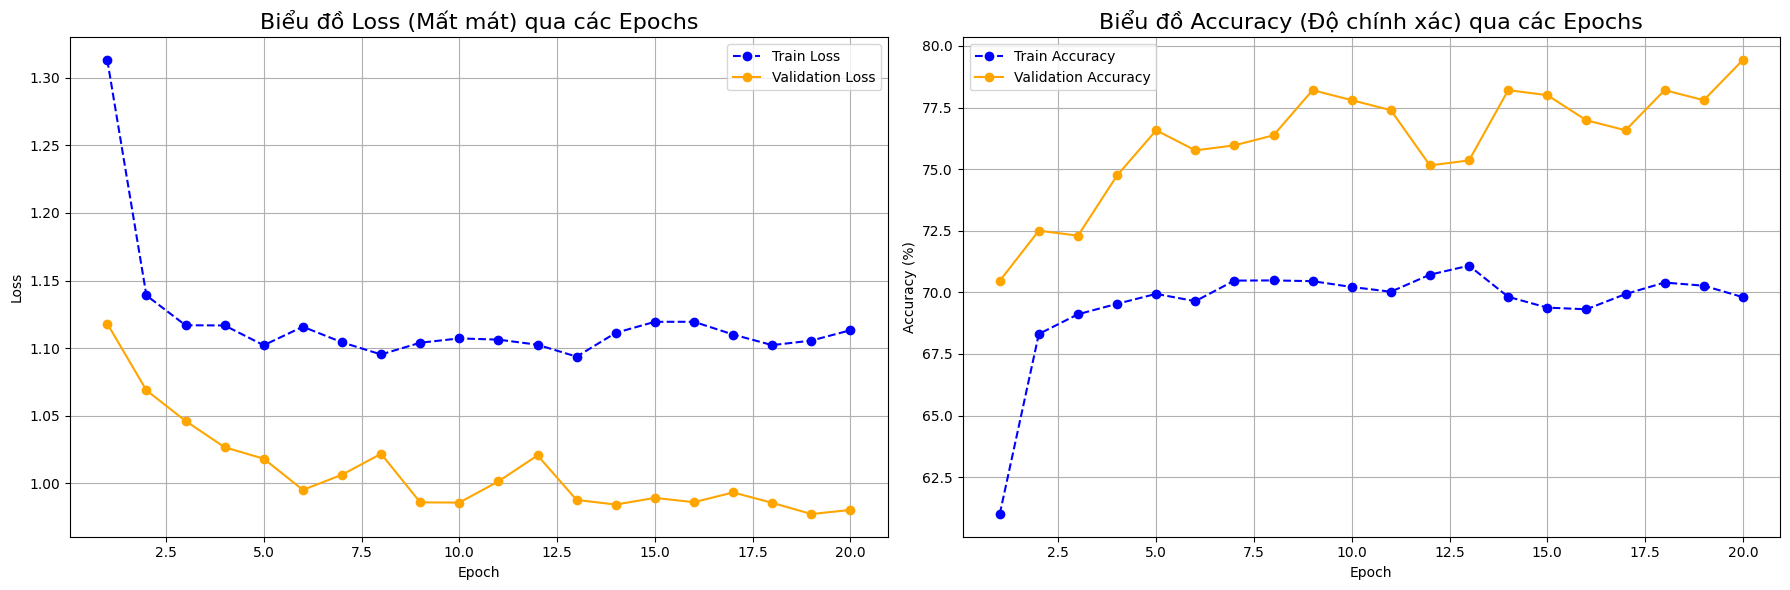

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    """
    Vẽ biểu đồ Loss và Accuracy từ history.
    (Phiên bản này tự động phát hiện số epochs)
    """

    # --- 1. Lấy dữ liệu từ history ---
    try:
        train_accu_list = history['train_acc']
        val_accu_list = history['val_acc']
        train_loss_list = history['train_loss']
        val_loss_list = history['val_loss']
    except KeyError as e:
        print(f"Lỗi: Không tìm thấy khóa {e} trong 'history'.")
        print("Hãy đảm bảo hàm 'fit' của bạn trả về dictionary với các khóa:")
        print("'train_acc', 'val_acc', 'train_loss', 'val_loss'")
        return

    # --- 2. TỰ ĐỘNG XÁC ĐỊNH SỐ EPOCHS ---
    actual_epochs_ran = len(train_accu_list)

    # Tạo danh sách các epoch
    epochs_list = list(range(1, actual_epochs_ran + 1))

    # --- 3. Tạo 2 biểu đồ con ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # --- Biểu đồ 1: Loss ---
    ax1.plot(epochs_list, train_loss_list, label='Train Loss', color='blue', marker='o', linestyle='--')
    ax1.plot(epochs_list, val_loss_list, label='Validation Loss', color='orange', marker='o')
    ax1.set_title('Biểu đồ Loss (Mất mát) qua các Epochs', fontsize=16)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # --- Biểu đồ 2: Accuracy ---
    ax2.plot(epochs_list, train_accu_list, label='Train Accuracy', color='blue', marker='o', linestyle='--')
    ax2.plot(epochs_list, val_accu_list, label='Validation Accuracy', color='orange', marker='o')
    ax2.set_title('Biểu đồ Accuracy (Độ chính xác) qua các Epochs', fontsize=16)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()

    plt.savefig('training_history_plot.png')
    print("\nĐã lưu biểu đồ vào file 'training_history_plot.png'")


# --- 3. Gọi hàm vẽ biểu đồ ---
print("\n--- Đang vẽ biểu đồ Loss và Accuracy ---")

plot_history(history_mineral)

## 📊 Nhận xét: Huấn luyện Toàn bộ (Fine-tuning) vs. Trích xuất Đặc trưng

Biểu đồ này cho thấy kết quả của việc "huấn luyện toàn bộ" (hoặc "tinh chỉnh" - fine-tuning) mô hình EfficientNetB0, thay vì chỉ dùng nó để trích xuất đặc trưng.

---

### 1. Phân tích Biểu đồ Huấn luyện

* **Accuracy (Độ chính xác):**
    * Độ chính xác trên tập Validation (màu cam) **bắt đầu ở mức cao (68%) và tăng dần, đạt đỉnh khoảng 77-78%**.
    * Độ chính xác trên tập Train (màu xanh) luôn **thấp hơn** tập Validation.

* **Loss (Mất mát):**
    * Tương tự, Validation Loss (màu cam) **luôn thấp hơn** Train Loss (màu xanh).

> **💡 Đây là một hiện tượng phổ biến và tích cực!**
>
> Việc validation accuracy cao hơn train accuracy **không phải là lỗi**. Điều này thường xảy ra khi mô hình sử dụng các kỹ thuật "chính quy hóa" (regularization) mạnh như **Dropout** hoặc **Data Augmentation** (tăng cường dữ liệu).
>
> * Khi huấn luyện, các kỹ thuật này được **bật lên**, khiến mô hình gặp khó khăn hơn (ví dụ: các neuron bị tắt ngẫu nhiên, ảnh bị bóp méo).
> * Khi đánh giá (validation), các kỹ thuật này được **tắt đi**, cho phép mô hình chạy với 100% công suất trên dữ liệu "sạch".
>
> Kết quả là, mô hình **không hề bị overfitting** (học vẹt). Thực tế, nó vẫn đang trong đà học tốt.

---

### 2. So sánh hiệu quả với các mô hình trước

Đây là bảng xếp hạng hiệu suất dựa trên **Accuracy cao nhất** trên tập test/validation:

1.  **🥇 SVM (với đặc trưng EfficientNet): 82.98%**
2.  **🥈 Logistic Regression (với đặc trưng EfficientNet): 78.29%**
3.  **🥉 Huấn luyện Toàn bộ EfficientNet (Fine-tuning): ~77-78%**
4.  **🏅 Random Forest (với đặc trưng EfficientNet): 74.21%**

---

### 3. Kết luận và Nhận xét

* **Chiến thắng bất ngờ:** Trong trường hợp này, phương pháp **Trích xuất Đặc trưng (Feature Extraction)** và sau đó sử dụng **SVM (Kernel RBF)** cho kết quả **vượt trội và rõ rệt** (gần 83%) so với việc huấn luyện toàn bộ mạng neural (chỉ ~78%).
* **Tại sao SVM lại thắng?**
    * **Đặc trưng "quá tốt":** Vector đặc trưng 1280 chiều từ EfficientNet (đã huấn luyện trên ImageNet) vốn dĩ đã **rất tốt** và có tính phân biệt cao.
    * **Sức mạnh của SVM:** SVM với kernel RBF cực kỳ hiệu quả trong việc tìm ra ranh giới phi tuyến tính phức tạp trong một **không gian đặc trưng có số chiều cao** (high-dimensional space).     
    * **Khó khăn của Fine-tuning:** Việc "tinh chỉnh" một mạng neural lớn như EfficientNet là một bài toán tối ưu hóa phức tạp. Nó có thể yêu cầu điều chỉnh learning rate cẩn thận, "đóng băng" (freeze) một số lớp, và huấn luyện trong thời gian dài. Rõ ràng, cách setup hiện tại chưa khai thác hết tiềm năng của nó và thậm chí còn cho kết quả thua cả Logistic Regression.

* **Ưu điểm của phương pháp SVM:**
    * **Hiệu quả cao nhất.**
    * **Tiết kiệm tài nguyên:** Bạn chỉ cần chạy trích xuất đặc trưng *một lần* (cần GPU). Sau đó, việc huấn luyện SVM (chỉ cần CPU) diễn ra **rất nhanh**, chỉ mất vài giây hoặc vài phút, thay vì hàng giờ để fine-tune mạng neural.

**➡️ Khuyến nghị:** Với bộ dữ liệu này, quy trình **EfficientNetB0 (Feature Extractor) + StandardScaler + SVM (Kernel RBF)** là phương pháp hiệu quả nhất, cân bằng giữa tốc độ và độ chính xác cao nhất.